<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/var/folders/nd/ckd2p671409_45_1_kmhw0bh0000gn/T/ipykernel_26257/2592598892.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(x_vol, hard_vol, label='Hard Volume: $\max(Z-z, 0)$', color='red', linewidth=3, linestyle='--')
/var/folders/nd/ckd2p671409_45_1_kmhw0bh0000gn/T/ipykernel_26257/2592598892.py:55: SyntaxWarning: invalid escape sequence '\m'
  ax2.plot(x_int, hard_int, label='Hard Intersection: $\max(z_A, z_B)$', color='red', linewidth=3, linestyle='--')


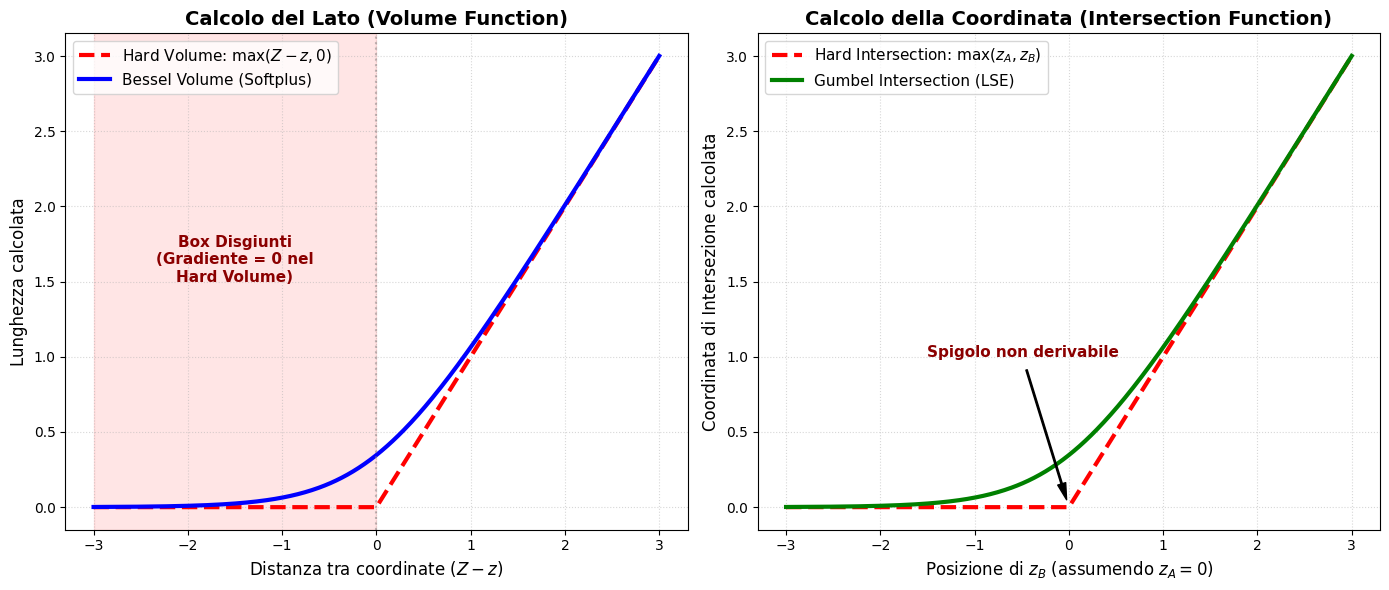

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Impostazioni grafiche
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# GRAFICO 1: Volume (Hard vs Bessel/Soft)
# ==========================================
# Asse X: Rappresenta la distanza tra i bordi (Z - z)
# Se x < 0, i box sono disgiunti. Se x > 0, si sovrappongono.
x_vol = np.linspace(-3, 3, 400)

# Hard Volume: max(x, 0)
hard_vol = np.maximum(x_vol, 0)

# Bessel/Soft Volume: Approssimazione tramite softplus
T = 0.5  # Temperatura del volume
gamma = 0.5772 # Costante di Euler-Mascheroni
beta = 0.5 # Temperatura di intersezione
# Formula della tesi: T * softplus((Z_i - z_i - 2*gamma*beta) / T)
# Per semplicità visiva, mostriamo il comportamento base della softplus rispetto al max(x,0)
bessel_vol = T * np.log(1 + np.exp((x_vol) / T)) 

ax1.plot(x_vol, hard_vol, label='Hard Volume: $\max(Z-z, 0)$', color='red', linewidth=3, linestyle='--')
ax1.plot(x_vol, bessel_vol, label='Bessel Volume (Softplus)', color='blue', linewidth=3)

# Annotazioni per il Volume
ax1.axvspan(-3, 0, color='red', alpha=0.1)
ax1.text(-1.5, 1.5, "Box Disgiunti\n(Gradiente = 0 nel\nHard Volume)", ha='center', color='darkred', fontsize=11, weight='bold')
ax1.axvline(0, color='gray', linestyle=':', alpha=0.5)

ax1.set_title("Calcolo del Lato (Volume Function)", fontsize=14, fontweight='bold')
ax1.set_xlabel('Distanza tra coordinate $(Z - z)$', fontsize=12)
ax1.set_ylabel('Lunghezza calcolata', fontsize=12)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.5)

# ==========================================
# GRAFICO 2: Intersezione (Hard vs Gumbel)
# ==========================================
# Fissiamo la coordinata z_A = 0. 
# Asse X: Rappresenta la coordinata z_B che varia.
x_int = np.linspace(-3, 3, 400)
z_A = 0

# Hard Intersection: max(z_A, z_B)
hard_int = np.maximum(z_A, x_int)

# Gumbel Intersection: Approssimazione LSE (LogSumExp)
beta_temp = 0.5
gumbel_int = beta_temp * np.log(np.exp(z_A/beta_temp) + np.exp(x_int/beta_temp))

ax2.plot(x_int, hard_int, label='Hard Intersection: $\max(z_A, z_B)$', color='red', linewidth=3, linestyle='--')
ax2.plot(x_int, gumbel_int, label='Gumbel Intersection (LSE)', color='green', linewidth=3)

# Annotazioni per l'Intersezione
ax2.annotate('Spigolo non derivabile', xy=(0, 0), xytext=(-1.5, 1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=11, color='darkred', weight='bold')

ax2.set_title("Calcolo della Coordinata (Intersection Function)", fontsize=14, fontweight='bold')
ax2.set_xlabel('Posizione di $z_B$ (assumendo $z_A = 0$)', fontsize=12)
ax2.set_ylabel('Coordinata di Intersezione calcolata', fontsize=12)
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

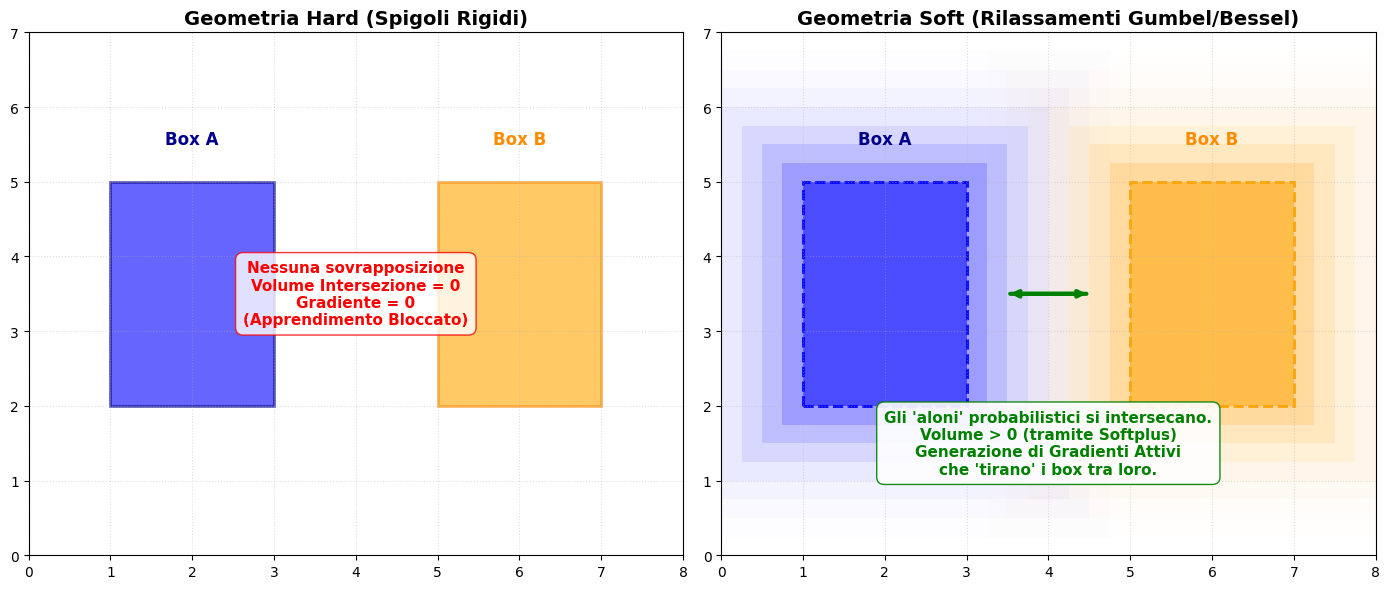

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Coordinate per due Box spazialmente disgiunti (es. un concetto "figlio" finito fuori dal "padre")
z_A, Z_A = (1, 2), (3, 5) # Box A (Padre teorico)
z_B, Z_B = (5, 2), (7, 5) # Box B (Figlio errante)

# ==========================================
# PANNELLO 1: Rappresentazione HARD (Rigida)
# ==========================================
# Disegno i box con confini netti e solidi
ax1.add_patch(patches.Rectangle(z_A, Z_A[0]-z_A[0], Z_A[1]-z_A[1], 
                                facecolor='blue', edgecolor='darkblue', linewidth=2, alpha=0.6))
ax1.add_patch(patches.Rectangle(z_B, Z_B[0]-z_B[0], Z_B[1]-z_B[1], 
                                facecolor='orange', edgecolor='darkorange', linewidth=2, alpha=0.6))

# Testo esplicativo
ax1.text(2, 5.5, 'Box A', color='darkblue', fontweight='bold', fontsize=12, ha='center')
ax1.text(6, 5.5, 'Box B', color='darkorange', fontweight='bold', fontsize=12, ha='center')
ax1.text(4, 3.5, 'Nessuna sovrapposizione\nVolume Intersezione = 0\nGradiente = 0\n(Apprendimento Bloccato)', 
         color='red', fontweight='bold', fontsize=11, ha='center', va='center', 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='red', boxstyle='round,pad=0.5'))

ax1.set_xlim(0, 8)
ax1.set_ylim(0, 7)
ax1.set_title("Geometria Hard (Spigoli Rigidi)", fontsize=14, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.4)

# ==========================================
# PANNELLO 2: Rappresentazione SOFT (Gumbel/Bessel Relaxations)
# ==========================================
# Funzione per disegnare il "campo probabilistico" (l'alone sfumato del box)
def draw_soft_box(ax, z, Z, color):
    # Il nucleo centrale
    ax.add_patch(patches.Rectangle(z, Z[0]-z[0], Z[1]-z[1], facecolor=color, alpha=0.5, edgecolor='none'))
    
    # Creazione degli aloni espansi per simulare la Softplus/LSE (la Temperatura)
    for i in range(1, 8):
        expansion = i * 0.25 # Quanto si allarga il bordo probabilistico
        alpha_val = 0.3 * (0.6 ** i) # L'intensità sfuma esponenzialmente
        
        ax.add_patch(patches.Rectangle(
            (z[0]-expansion, z[1]-expansion), 
            (Z[0]-z[0]) + 2*expansion, 
            (Z[1]-z[1]) + 2*expansion, 
            facecolor=color, edgecolor='none', alpha=alpha_val
        ))
    # Disegno un bordo tratteggiato per indicare il confine "teorico"
    ax.add_patch(patches.Rectangle(z, Z[0]-z[0], Z[1]-z[1], fill=False, edgecolor=color, linestyle='--', linewidth=2))

# Disegno i box sfumati
draw_soft_box(ax2, z_A, Z_A, 'blue')
draw_soft_box(ax2, z_B, Z_B, 'orange')

# Aggiungo frecce che mostrano l'attrazione causata dal gradiente non nullo
ax2.annotate('', xy=(3.5, 3.5), xytext=(4.5, 3.5), 
             arrowprops=dict(arrowstyle="->", color='green', lw=3))
ax2.annotate('', xy=(4.5, 3.5), xytext=(3.5, 3.5), 
             arrowprops=dict(arrowstyle="->", color='green', lw=3))

# Testo esplicativo
ax2.text(2, 5.5, 'Box A', color='darkblue', fontweight='bold', fontsize=12, ha='center')
ax2.text(6, 5.5, 'Box B', color='darkorange', fontweight='bold', fontsize=12, ha='center')
ax2.text(4, 1.5, "Gli 'aloni' probabilistici si intersecano.\nVolume > 0 (tramite Softplus)\nGenerazione di Gradienti Attivi\nche 'tirano' i box tra loro.", 
         color='green', fontweight='bold', fontsize=11, ha='center', va='center', 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='green', boxstyle='round,pad=0.5'))

ax2.set_xlim(0, 8)
ax2.set_ylim(0, 7)
ax2.set_title("Geometria Soft (Rilassamenti Gumbel/Bessel)", fontsize=14, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

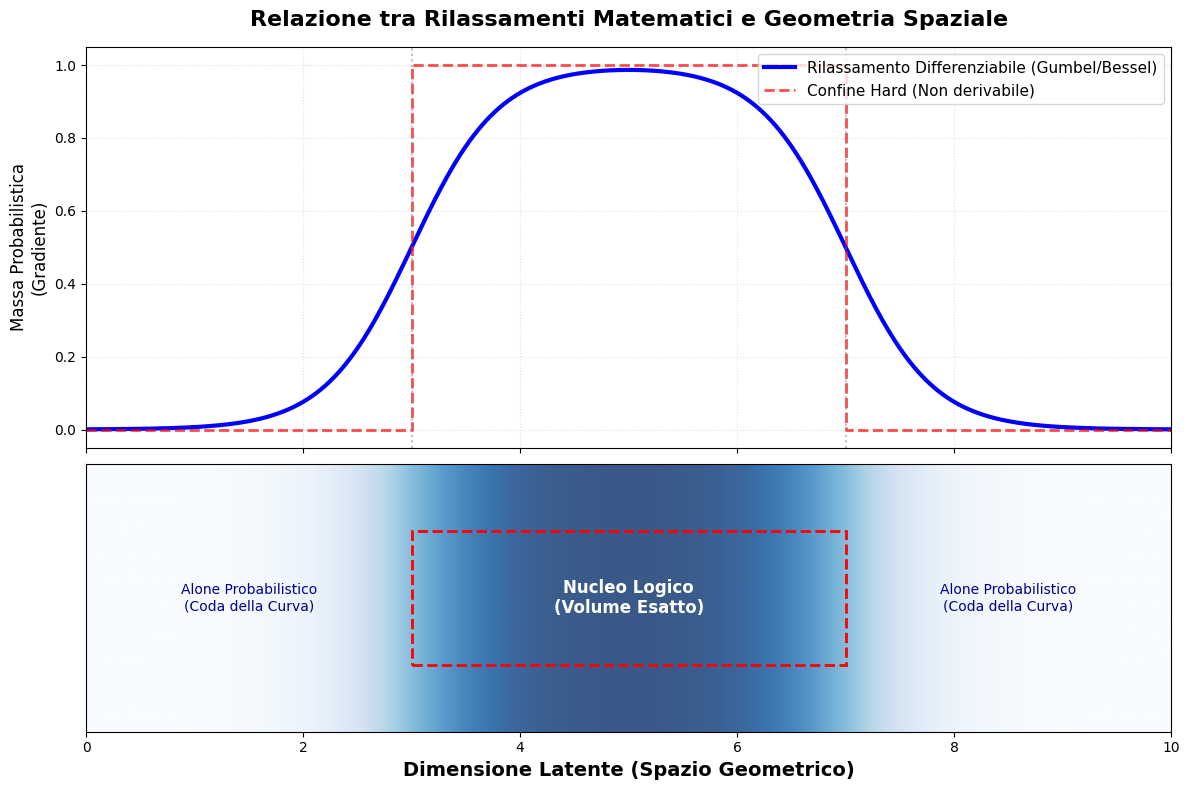

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.style.use('default')
# Creiamo due grafici impilati che condividono l'asse X
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [1.5, 1]})

# Impostiamo lo spazio e i confini del Box
x = np.linspace(0, 10, 500)
z_val, Z_val = 3, 7
temperature = 0.4 # Rappresenta i parametri T (Volume) o beta (Gumbel)

# Simuliamo la curva probabilistica derivata dalle approssimazioni Softplus/LSE
# Usiamo una sigmoide per replicare visivamente il decadimento ai bordi
left_boundary = 1 / (1 + np.exp(-(x - z_val) / temperature))
right_boundary = 1 / (1 + np.exp((x - Z_val) / temperature))
prob_curve = left_boundary * right_boundary

# ==========================================
# PANNELLO SUPERIORE: La Curva Matematica
# ==========================================
ax1.plot(x, prob_curve, color='blue', linewidth=3, label='Rilassamento Differenziabile (Gumbel/Bessel)')

# Aggiungiamo i confini rigidi (Hard) per confronto
ax1.plot([0, z_val, z_val, Z_val, Z_val, 10], [0, 0, 1, 1, 0, 0], 
         color='red', linestyle='--', linewidth=2, label='Confine Hard (Non derivabile)', alpha=0.7)

# Linee di connessione con il pannello inferiore
ax1.axvline(z_val, color='gray', linestyle=':', alpha=0.5)
ax1.axvline(Z_val, color='gray', linestyle=':', alpha=0.5)

ax1.set_title("Relazione tra Rilassamenti Matematici e Geometria Spaziale", fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel("Massa Probabilistica\n(Gradiente)", fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.4)

# ==========================================
# PANNELLO INFERIORE: Il Box e l'Alone
# ==========================================
# Creiamo l'alone spalmando la curva probabilistica come una mappa di calore (heatmap)
extent = [x.min(), x.max(), 0, 2]
ax2.imshow(np.tile(prob_curve, (10, 1)), extent=extent, cmap='Blues', aspect='auto', alpha=0.8)

# Disegniamo il contorno del "Nucleo Hard" per evidenziare la differenza
core_box = patches.Rectangle((z_val, 0.5), Z_val - z_val, 1, fill=False, edgecolor='red', linestyle='--', linewidth=2)
ax2.add_patch(core_box)

# Annotazioni
ax2.text(5, 1, "Nucleo Logico\n(Volume Esatto)", ha='center', va='center', color='white', fontweight='bold', fontsize=12)
ax2.text(1.5, 1, "Alone Probabilistico\n(Coda della Curva)", ha='center', va='center', color='darkblue', fontsize=10)
ax2.text(8.5, 1, "Alone Probabilistico\n(Coda della Curva)", ha='center', va='center', color='darkblue', fontsize=10)

# Formattazione finale
ax2.set_xlabel("Dimensione Latente (Spazio Geometrico)", fontsize=14, fontweight='bold')
ax2.set_yticks([]) # Rimuoviamo i numeri sull'asse Y spaziale perché non servono
ax2.set_ylim(0, 2)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05) # Riduciamo lo spazio per enfatizzare la connessione
plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/var/folders/nd/ckd2p671409_45_1_kmhw0bh0000gn/T/ipykernel_26257/729347977.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax.text(4, 4.5, "Intersezione HARD\n$z_{int} = \max(z_A, z_B)$", ha='center', va='center', fontweight='bold')


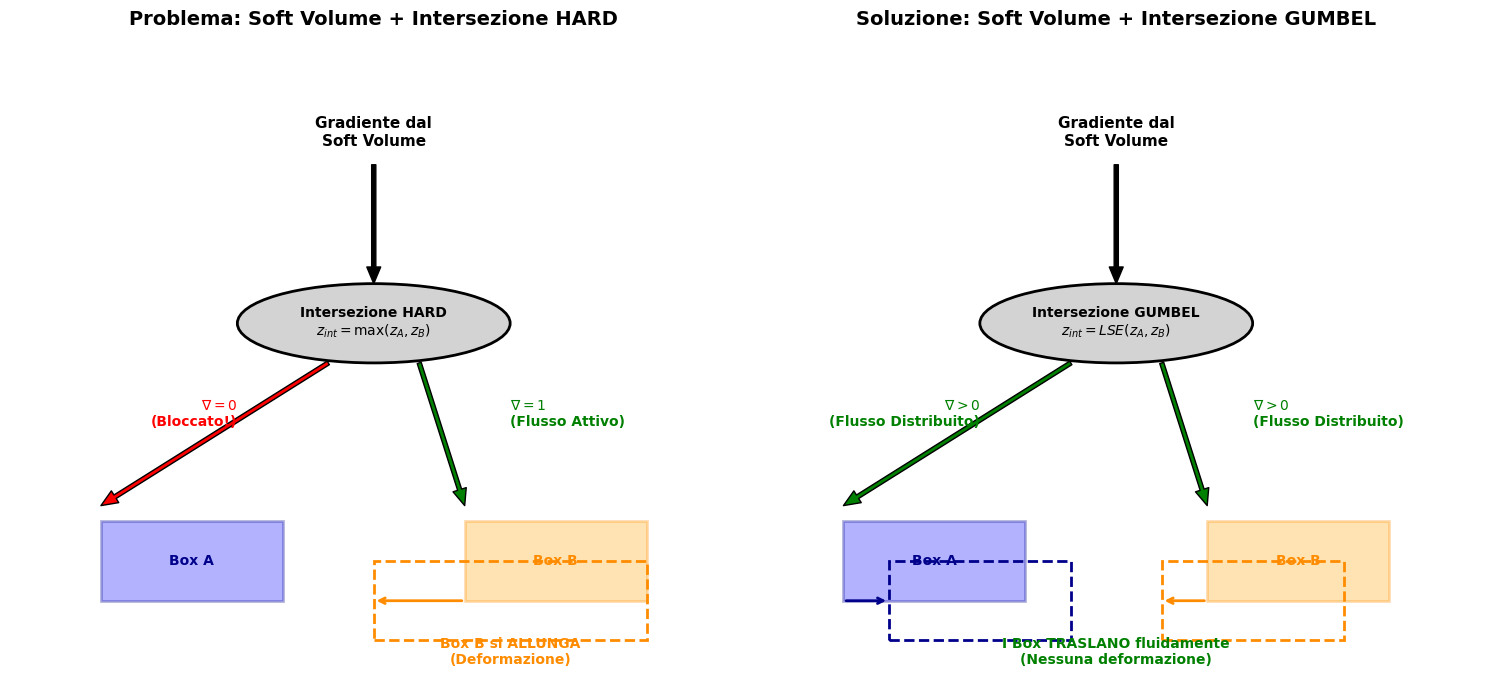

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

def draw_gradient_flow(ax, title, is_hard=True):
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    
    # 1. Disegno i Box di partenza (Box A e Box B disgiunti)
    # Box A: z=1, Z=3 | Box B: z=5, Z=7
    ax.add_patch(patches.Rectangle((1, 1), 2, 1, facecolor='blue', alpha=0.3, edgecolor='darkblue', lw=2))
    ax.add_patch(patches.Rectangle((5, 1), 2, 1, facecolor='orange', alpha=0.3, edgecolor='darkorange', lw=2))
    ax.text(2, 1.5, 'Box A', ha='center', va='center', fontweight='bold', color='darkblue')
    ax.text(6, 1.5, 'Box B', ha='center', va='center', fontweight='bold', color='darkorange')
    
    # 2. Nodo Computazionale (Il calcolo dell'intersezione)
    ax.add_patch(patches.Ellipse((4, 4.5), 3, 1, facecolor='lightgray', edgecolor='black', lw=2))
    if is_hard:
        ax.text(4, 4.5, "Intersezione HARD\n$z_{int} = \max(z_A, z_B)$", ha='center', va='center', fontweight='bold')
    else:
        ax.text(4, 4.5, "Intersezione GUMBEL\n$z_{int} = LSE(z_A, z_B)$", ha='center', va='center', fontweight='bold')
        
    # 3. Flusso del gradiente in ingresso (Dal Soft Volume)
    ax.annotate('', xy=(4, 5.0), xytext=(4, 6.5), arrowprops=dict(facecolor='black', width=3, headwidth=10))
    ax.text(4, 6.7, "Gradiente dal\nSoft Volume", ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 4. Flusso del gradiente in uscita (Verso i parametri z_A e z_B)
    if is_hard:
        # HARD: Il max(1, 5) è 5 (cioè z_B). Il gradiente va TUTTO a z_B.
        # Freccia verso z_B (Verde = Flusso attivo)
        ax.annotate('', xy=(5, 2.2), xytext=(4.5, 4.0), arrowprops=dict(facecolor='green', width=3, headwidth=10))
        ax.text(5.5, 3.2, "$\\nabla = 1$\n(Flusso Attivo)", color='green', fontweight='bold', ha='left')
        
        # Freccia verso z_A (Rossa = Flusso bloccato)
        ax.annotate('', xy=(1, 2.2), xytext=(3.5, 4.0), arrowprops=dict(facecolor='red', width=3, headwidth=10))
        ax.text(2.5, 3.2, "$\\nabla = 0$\n(Bloccato!)", color='red', fontweight='bold', ha='right')
        
        # Effetto Fisico: Solo il bordo sinistro di B si muove. Il box si DEFORMA.
        ax.add_patch(patches.Rectangle((4, 0.5), 3, 1, fill=False, edgecolor='darkorange', linestyle='--', lw=2))
        ax.text(5.5, 0.2, "Box B si ALLUNGA\n(Deformazione)", ha='center', color='darkorange', fontweight='bold')
        ax.annotate('', xy=(4, 1), xytext=(5, 1), arrowprops=dict(arrowstyle="->", color='darkorange', lw=2))
        
    else:
        # SOFT (Gumbel): Il gradiente si divide proporzionalmente
        # Freccia verso z_B (Verde)
        ax.annotate('', xy=(5, 2.2), xytext=(4.5, 4.0), arrowprops=dict(facecolor='green', width=3, headwidth=10))
        ax.text(5.5, 3.2, "$\\nabla > 0$\n(Flusso Distribuito)", color='green', fontweight='bold', ha='left')
        
        # Freccia verso z_A (Verde)
        ax.annotate('', xy=(1, 2.2), xytext=(3.5, 4.0), arrowprops=dict(facecolor='green', width=3, headwidth=10))
        ax.text(2.5, 3.2, "$\\nabla > 0$\n(Flusso Distribuito)", color='green', fontweight='bold', ha='right')
        
        # Effetto Fisico: Entrambi i box TRASLANO dolcemente
        ax.add_patch(patches.Rectangle((1.5, 0.5), 2, 1, fill=False, edgecolor='darkblue', linestyle='--', lw=2))
        ax.annotate('', xy=(1.5, 1), xytext=(1, 1), arrowprops=dict(arrowstyle="->", color='darkblue', lw=2))
        
        ax.add_patch(patches.Rectangle((4.5, 0.5), 2, 1, fill=False, edgecolor='darkorange', linestyle='--', lw=2))
        ax.annotate('', xy=(4.5, 1), xytext=(5, 1), arrowprops=dict(arrowstyle="->", color='darkorange', lw=2))
        
        ax.text(4, 0.2, "I Box TRASLANO fluidamente\n(Nessuna deformazione)", ha='center', color='green', fontweight='bold')

    # Formattazione assi
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 8)
    ax.axis('off') # Nascondiamo la griglia cartesiana per far risaltare il grafo

draw_gradient_flow(ax1, "Problema: Soft Volume + Intersezione HARD", is_hard=True)
draw_gradient_flow(ax2, "Soluzione: Soft Volume + Intersezione GUMBEL", is_hard=False)

plt.tight_layout()
plt.show()